### 1. Initalization

Initializes the imports and global parameters that we will use. Global parameters are defined in file *param_multi_mask* and also in this initial section, and most of the imports are done on *imports* as well as some functions from *tools* and *satellite_sim*.

In [1]:
## ----- IPYTHON COMMANDS ----- ##
# autoreload: Reloads all imported modules automatically, then we only need to import them again (no need to restart the kernel)
%load_ext autoreload
%autoreload 2

In [2]:
## ----- IMPORTS ----- ##
from satellite_RFI.src import tools  # <-- some useful functions
from satellite_RFI.src.satellite_sims import satellite_sim as ss  # <-- object for the satellite simulationobject for the satellite simulation
import natsort  # <-- to sort strings with numbers
import sys
sys.path.insert(0, '../../param_import/')  # <-- alters the path that searches for imports
from imports import *  # <-- file with the general imports (numpy, astropy, matplotlib, etc)
from matplotlib.ticker import MaxNLocator


## ----- GLOBAL PARAMETERS ----- ##
# Couldn't most of these go to the param_multi_mask file? XXX
import param_multi_mask as pm  # <-- defines general variables
savefig = True
blocks = ['1551055211']  # <-- we start with just one block
folders = ['test_results_sat_12']
sat_cat = '../../Satellite_Catalogue/satellite_constellation_catalog.csv'


Data Path exists
Importing masking parameters...


In [3]:
def katdal_information(path):
    '''
    Function for looking up the katdal information.

    Parameters
    ----------
    path : string
        Path to the file with katdal information.

    Returns
    -------
    nd_s0 : (?)
    nd_s0_coords : (?)
    nd_s0_coords2 : (?)
    nd_s0_pos : (?)
    frequency : (?)
    '''

    # different encodings for python 2 or 3
    if sys.version_info.major==2:
        katdal_info = pickle.load(open(path + '_katdal_info.p', 'rb'))
    elif sys.version_info.major==3:
        katdal_info = pickle.load(open(path + '_katdal_info.p', 'rb'), encoding = 'latin1')

    # retrieving specific parameters
    nd_s0 = katdal_info['nd_s0']
    nd_s0_coords = katdal_info['nd_s0_coords']
    nd_s0_coords2 = katdal_info['nd_s0_coords2']
    nd_s0_pos = katdal_info['nd_s0_pos']
    frequency = katdal_info['frequency']
    
    return nd_s0, nd_s0_coords, nd_s0_coords2, nd_s0_pos, frequency



### 2. Chi-Square Method

Defines the function `chisq_func2`, which computes the chi-square method with the parameters specified (C1 vs. C2, and using a specific masking or not).

In [4]:
## ----- CHI-SQUARE METHOD ----- ##
def chisq_func2(block_id, a_param, s_param = None, damper = None, satellites_only = False,
                sat_info = pm.satellite_catalogue, add_sub = [True,False], frequency_slice = False, 
                time_slice = False, t_mask = False, d_mask = False, pt_mask = False, time_avg = False, 
                chi_sigma = False, verbose = False):
    '''
    Computes the chi-squared value using the data, simulation, and masking parameters.

    Parameters (XXX complete!)
    ----------

    Returns (XXX complete!)
    -------
    data : 
    simulation : 
    chi_sq_N : 
    frange_slice : 
    time_idx : (optional)
    '''

    # retrieving katdal information
    folder = '/idia/projects/hi_im/satellite_rfi/Testing/' + block_id + '/'
    nd_s0, nd_s0_coords, nd_s0_coords2, nd_s0_pos, frequency = katdal_information(folder + block_id)

    # necessary to select nearby satellites for angular masking beforehand
    if d_mask == False:  satellites = None
    else:  satellites = folder + 'nearby_satellites/nearby_satellite_close_angle_' + d_mask + '.p'

    # search later what this class does XXX
    """INITIALIZING THE SATELLITE FUNCTION"""
    sat = ss(
        file_name = block_id, 
        sats_only = satellites_only, 
        data_loc = folder, 
        sat_loc = folder, 
        survey_info = [nd_s0, nd_s0_coords, frequency], 
        sat_info = sat_info,
        plots_loc = folder,
        sat_beam = pm.beam_model + '_beam_' + str(pm.fs) + '_' + str(pm.fe) + 'MHz', 
        frequency_range = [pm.fs, pm.fe], 
        constellations = pm.constellations_remain, 
        nearby_satellites = satellites,
        verbose = False
    )

    # search later what this function does XXX
    """EXECUTING THE SATELLITE SIM FUNCTION"""
    sat.excecute(
        a_param = a_param, 
        obs_time_start = time_slice[0], 
        obs_time_end = time_slice[1], 
        obs_frequency_start = frequency_slice[0], 
        obs_frequency_end = frequency_slice[1], 
        file_bias_choice = pm.bias, 
        add_sub = add_sub, 
        attenuation_func = damper, 
        attenuation_sigma = s_param, 
        bandsize = None,
        verbose = False
    )

    # defining the frequency band (why do we need to do this? XXX)
    frange_slice = sat.frequency_band[ sat.frequency_idx[0] : sat.frequency_idx[1] ]
    data_sim = sat.simulation_TOD_slice.T
    data_cal = sat.calibration_data_slice.T
    
    # choosing the masking
    if t_mask != False:
        print ("Thermal mask: " + str(t_mask) + " Kelvin.")
        mask = data_cal > t_mask

    elif d_mask != False:
        print ("Angular mask: " + str(d_mask) + " degrees.")
        mask = sat.mask_nearby_satellites_slice

    elif pt_mask != False:
        print ("Pixel timeline mask: " + str(pt_mask) + " Kelvin.")
        mask = tools.time_line_masker(data_in = data_cal, t_value = pt_mask)
        
    else:
        print ("No masking applied")
        mask = None

    # get masked data
    simulation = np.ma.array(data = data_sim, mask = mask)
    data = np.ma.array(data = data_cal, mask = mask)
        
    # time avering
    if time_avg != False:
        print ("Time averaging for every " + str(time_avg) + " seconds.")
        # Averaging over time - MISSING TIMER PARAMETER (? XXX)
        time_idx = sat.time_idx
        timer = nd_s0[ time_idx[0] : time_idx[1] ]
        data = tools.waterfall_avg_time(timer=timer, size=time_avg, waterfall=data)
        simulation = tools.waterfall_avg_time(timer=timer, size=time_avg, waterfall=simulation)

    # calculating the cost function
    chi_num = simulation - data
    if chi_sigma == True:  sig = data
    else:  sig = 1
    chi_sq = np.ma.sum((chi_num/sig)**2)
    chi_sq_N = chi_sq / np.ma.size(data)

    # writing the values obtained
    if verbose == True:
        print ("Chi numerator value: " + str(np.ma.sum(chi_num)))
        print ("Chi Square value: " + str(chi_sq))
        print ("Chi Square N value: " + str(chi_sq_N))

    # returning values
    if time_avg != False:  return data, simulation, chi_sq_N, frange_slice, time_idx
    else:  return data, simulation, chi_sq_N, frange_slice



# Figures from the article

### 1. No-Masking Simulation

This part recovers the figures that are presented in Section 4.1 of the article (without any masking).

In [22]:
## ----- FUNCTION alphas ----- ##
def alphas(block_id, folder_id):
    ''' 
    Function to return the fractional (C1) and residual (C2) alpha values.

    Parameters
    ----------
    block_id : string
        Path to the folder of the block.
    folder_id : string
        Folder with the data corresponding to the chosen mask.

    Returns
    -------
    frac : list
        (?)
    resi : list
        (?)
    '''

    # getting the folder with values
    loc = '/idia/projects/hi_im/satellite_rfi/Testing/' + block_id + '/' + folder_id
    file_list = os.listdir(loc)
    file_list = natsort.natsorted(file_list, key=lambda y: y.lower())
    #files = ["/users/bvitoria/workspace/iara_angular1_C1.p","/users/bvitoria/workspace/iara_angular1_C2.p",
    #        "/users/bvitoria/workspace/iara_angular5_C1.p","/users/bvitoria/workspace/iara_angular5_C2.p"]

    # selecting the C1 and C2 files
    idx = np.arange(len(file_list))
    even_idx = idx[::2]
    frac = [pickle.load(open(loc+file_list[di],'rb')) for di in even_idx]
    #frac = [pickle.load(open(files[di],'rb')) for di in even_idx]
    odd_idx = idx[1::2]
    resi = [pickle.load(open(loc+file_list[di],'rb')) for di in odd_idx]
    #resi = [pickle.load(open(files[di],'rb')) for di in odd_idx]
    
    return frac, resi


In [13]:
# --------------------
def no_mask_alpha_plot(frac, resi, block_id):
    ''' Function to plot out the alpha values for the no mask scenario (it's different from the other plots). '''

    # creating figure
    fig, ax = plt.subplots(figsize=(10, 4), nrows=1, ncols=1)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xticks(range(1, 21 + 1))
    ax.set_title(r'Block: ' + block_id + ' No-Mask')
    ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')
    ax.set_ylabel('Amplitude')

    # plotting values
    ax.plot(np.arange(1,22), frac['best-fit'], 'o', label=r'$\sigma_{D}=C_1$')
    ax.plot(np.arange(1,22), resi['best-fit'], '*', label=r'$\sigma_{D}=C_2$')
    ax.axhline(0, color='black', linestyle='--')

    # saving the figure
    ax.legend()
    fig.tight_layout()
    if savefig==True:  
        #fig.savefig('./nm_fitting_alpha.pdf')
        fig.savefig("/users/bvitoria/workspace/brandon_nomask.pdf")
    fig.show()


# ------------------    
def no_mask_simulation_1d_plot(frac, resi, frequency, block_id):
    ''' Function for plotting the comparison between the data and simulation for 1d. '''

    # creating figures
    fig, axs = plt.subplots(figsize=(20, 4), ncols=2, nrows=1, sharex=True, sharey=True)
    fig.suptitle(r'Block: ' + block_id + ' No-Mask')

    # ----- FIRST FIGURE (C1 values) -----
    # defining figure
    ax = axs[0]
    ax.set_ylabel('Temperature [K]')
    ax.set_xlabel('Frequency [MHz]')
    textstr = '\n'.join((r'$\sigma_{D}=C_1$', r'FoM$=%.5f$' % (np.round(frac[2], 5), ), ))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

    # plotting
    ax.plot(frequency, np.mean(frac[0], axis=0), label='Observation')
    ax.plot(frequency, np.mean(frac[1], axis=0), '--', label='Simulation')
    ax.text(0.685, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
    ax.legend(loc="upper left")

    # ----- SECOND FIGURE (C2 values) -----
    # defining figure
    ax=axs[1]
    ax.set_ylabel('Temperature [K]')
    ax.set_xlabel('Frequency [MHz]')
    textstr = '\n'.join((r'$\sigma_{D}=C_2$', r'FoM$=%.2f$' % (np.round(resi[2], 2), ), ))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

    # plotting
    ax.plot(frequency, np.mean(resi[0], axis=0), label='Observation')
    ax.plot(frequency, np.mean(resi[1], axis=0), '--', label='Simulation')
    ax.text(0.685, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
    ax.legend(loc="upper left")

    # saving figures
    fig.tight_layout()
    if savefig==True:  
        #fig.savefig('./no_mask_best_fit_1d.pdf')
        fig.savefig("/users/bvitoria/workspace/brandon_nomask_1d.pdf")
    fig.show()


# --------------------
def no_mask_simulation_2d_plot(plot_info, frequency, block_id):
    ''' Function to plot the 2d no mask scenario plot. '''

    # retrieving values
    path = '/idia/projects/hi_im/satellite_rfi/Testing/' + block_id + '/' + block_id
    nd_s0, nd_s0_coords, nd_s0_coords2, nd_s0_pos, frequency = katdal_information(path)

    # creating figures
    plots_title = ['Observation', r'$C_1$', r'$C_2$']
    fig, axs = plt.subplots(figsize=(12, 4), nrows=1, ncols=3, sharey=True)
    fig.suptitle(r'Block: ' + block_id + ' No-Mask')  

    # plotting for each graph
    for i in range(len(plot_info)):
        ax = axs[i]
        cax = ax.imshow(plot_info[i], aspect='auto', 
                        extent=[frequency[0], frequency[-1], nd_s0[-1], nd_s0[0]], 
                        vmax=np.max(plot_info[0]), vmin=np.min(plot_info[0]))
        cbar = fig.colorbar(cax, ax=ax)
        cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
        ax.set_title(plots_title[i])
        ax.set_ylabel('Time [sec]')
        ax.set_xlabel('Frequency [MHz]')

    # saving figures
    fig.tight_layout()
    if savefig==True:
        #fig.savefig('./no_mask_best_fit_2d.pdf')
        fig.savefig("/users/bvitoria/workspace/brandon_nomask_2d.pdf")
    fig.show()



No masking applied
No masking applied


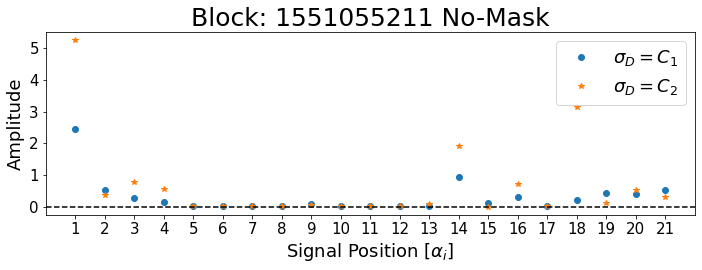

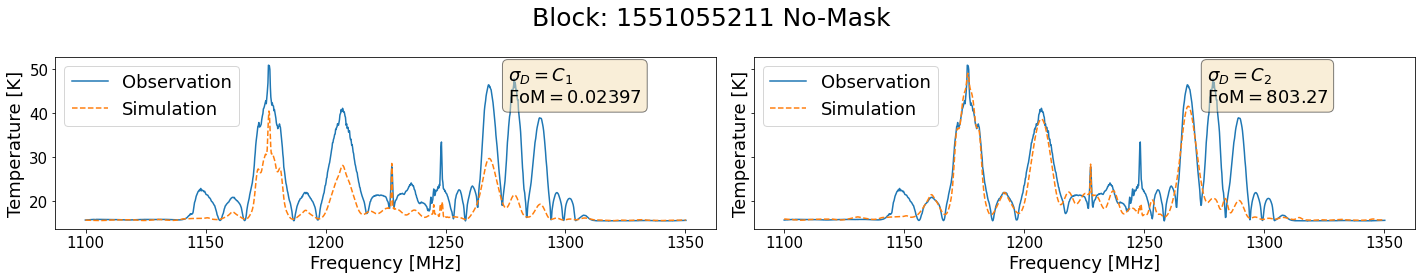

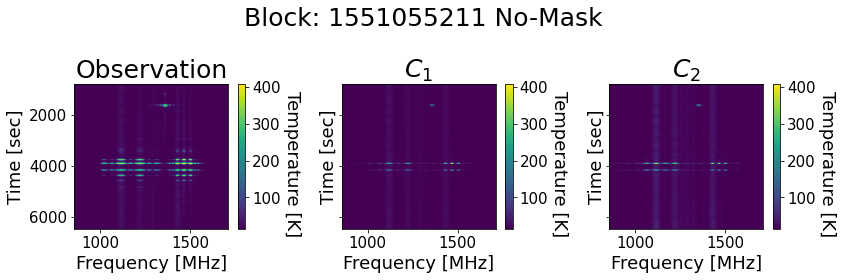

In [14]:
# dictionary with all alpha values per block
no_mask_dic = {}

for bi in range(len(blocks)):
    # retrieving alpha values and adding to a dictionary
    frac, resi = alphas(block_id=blocks[bi], folder_id=folders[bi]+'/no_mask/')
    frac = frac[0];  resi = resi[0]
    no_mask_dic.update({blocks[bi] : [frac, resi]})

    # plotting the alpha values
    no_mask_alpha_plot(frac=frac, resi=resi, block_id=blocks[bi])
    
    # simulation for C1 and C2 values
    mno_sf = chisq_func2(block_id=blocks[bi], a_param=frac['best-fit'], s_param=None, damper=None, sat_info=sat_cat, frequency_slice=[1100,1350], 
                         time_slice=[None,None], t_mask=False, d_mask=False, time_avg=False, chi_sigma=True, verbose=False)
    mno_sr = chisq_func2(block_id=blocks[bi],a_param=resi['best-fit'], s_param=None, damper=None, sat_info=sat_cat, frequency_slice=[1100,1350],
                         time_slice=[None,None], t_mask=False, d_mask=False, time_avg=False, chi_sigma=False, verbose=False)
    f_slice = mno_sr[3]

    # plotting the values
    no_mask_simulation_1d_plot(frac=mno_sf, resi=mno_sr, frequency=f_slice, block_id=blocks[bi])
    no_mask_simulation_2d_plot(plot_info=[mno_sr[0],mno_sf[1],mno_sr[1]], frequency=f_slice, block_id=blocks[bi])



### 2. Masking - Angular Simulation

This part recovers the figures from Section 4.2.1 (with angular masking)

In [24]:
## ----- FUNCTION alpha_plot ----- ##
def alpha_plot(frac, resi, block_id, labels, title, savefig_name):
    ''' Plot the alpha values for C1 and C2 for a given masking. '''

    # creating figures
    ls = ['o', '*', 'x', '.', 'o']
    fig, axs = plt.subplots(figsize=(10, 8), nrows=2, ncols=1, sharey=True)
    fig.suptitle(r'Block: '+block_id+' '+title+" Mask")
    for i,ax in enumerate(axs):
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_xticks(range(1, 21 + 1))
        ax.set_ylabel('Amplitude')
        textstr = '\n'.join((r'$\sigma_D=C_{}$'.format(i+1), ), )
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
        ax.axhline(0, color='black', linestyle='--')
    axs[1].set_xlabel(r'Signal Position $[\alpha_{i}]$')

    # plotting graphs
    for di in range(len(frac)):  axs[0].plot(np.arange(1,22), frac[di]['best-fit'], ls[di], label=title+r': '+labels[di])
    for di in range(len(frac)):  axs[1].plot(np.arange(1,22), resi[di]['best-fit'], ls[di], label=title+r': '+labels[di])
    axs[1].legend()
    
    # saving figure
    fig.tight_layout()
    if savefig==True:  
        #fig.savefig(savefig_name)
        fig.savefig("/users/bvitoria/workspace/brandon_angular.pdf")
    fig.show()



In [25]:
## ----- FUNCTION simulation_1d ----- ##
def simulation_1d(frac, resi, block_id, labels, title, savefig_name=None):
    ''' Function that plots the 1d simulation results for a given mask. '''

    # creating figure
    fig, axs = plt.subplots(figsize=(20, 3*len(labels)), nrows=len(labels), ncols=2, sharey=True)
    fig.suptitle(r'Block: '+block_id+' '+title+' Mask')

    for i in range(2):
        # choosing between C1 and C2
        if i==0:  data = frac
        else:  data = resi
        
        # plotting values for observation and simulation
        for ri in range(len(labels)):
            ax=axs[ri,i]
            textstr = '\n'.join((r'$\sigma_D=C_{}$'.format(i+1), f'{title}='+labels[ri], r'FoM$=%.5f$' % (np.round(data[ri][2], 5), ), ))
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
            if ri==1:  ax.set_xlabel('Frequency [MHz]')
            ax.set_ylabel('Temperature [K]')
            ax.plot(data[ri][3], np.mean(data[ri][0], axis=0), label='Observation')
            ax.plot(data[ri][3], np.mean(data[ri][1], axis=0), '--', label='Simulation')
            ax.legend(loc='upper right')

    fig.tight_layout()
    if savefig==True:  
        #fig.savefig(savefig_name)
        fig.savefig("/users/bvitoria/workspace/brandon_angular_1d.pdf")
    fig.show()



In [26]:
## ----- FUNCTION simulation_2d ----- ##
def simulation_2d(frac, resi, block_id, labels, title, savefig_name):
    ''' Function for plotting the 2d information of the observation vs the model in fractional and residual '''

    # creating figure
    nd_s0, _, _, _, _ = katdal_information('/idia/projects/hi_im/satellite_rfi/Testing/'+block_id+'/'+block_id)
    plots_title = ['Observation', r'$C_1$', r'$C_2$']
    fig, axs = plt.subplots(figsize=(16, 3*len(labels)), nrows=len(labels), ncols=3, sharey=True, sharex=True)
    fig.suptitle(r'Block: '+block_id+' '+title+' Mask')

    # plotting graphs
    for ri in range(len(labels)):
        for ci in range(3):
            ax = axs[ri,ci]
            ext1 = resi[ri][3][0]
            ext2 = resi[ri][3][-1]
            vmax = np.max(resi[ri][0])
            vmin = np.min(resi[ri][0])

            if ci==0:  cax = ax.imshow(resi[ri][0], aspect='auto', extent=[ext1,ext2,nd_s0[-1],nd_s0[0]], vmax=vmax, vmin=vmin)
            elif ci==1:  cax = ax.imshow(frac[ri][0], aspect='auto', extent=[ext1,ext2,nd_s0[-1],nd_s0[0]], vmax=vmax, vmin=vmin)
            elif ci==2:  cax = ax.imshow(resi[ri][1], aspect='auto', extent=[ext1,ext2,nd_s0[-1],nd_s0[0]], vmax=vmax, vmin=vmin)

            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
            if ri==0:  ax.set_title(plots_title[ci])
            if ri==1:  ax.set_xlabel('Frequency [MHz]')
            if ci==0:  ax.set_ylabel('Time [sec]')

    fig.tight_layout()
    if savefig==True:  
        #fig.savefig(savefig_name)
        fig.savefig("/users/bvitoria/workspace/brandon_angular_2d.pdf")
    fig.show()



Angular mask: 1F degrees.
Angular mask: 5F degrees.
Angular mask: 1F degrees.
Angular mask: 5F degrees.


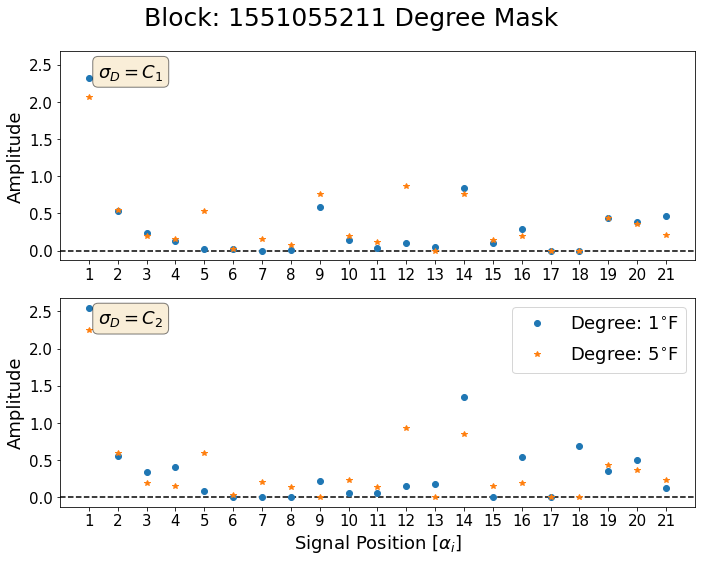

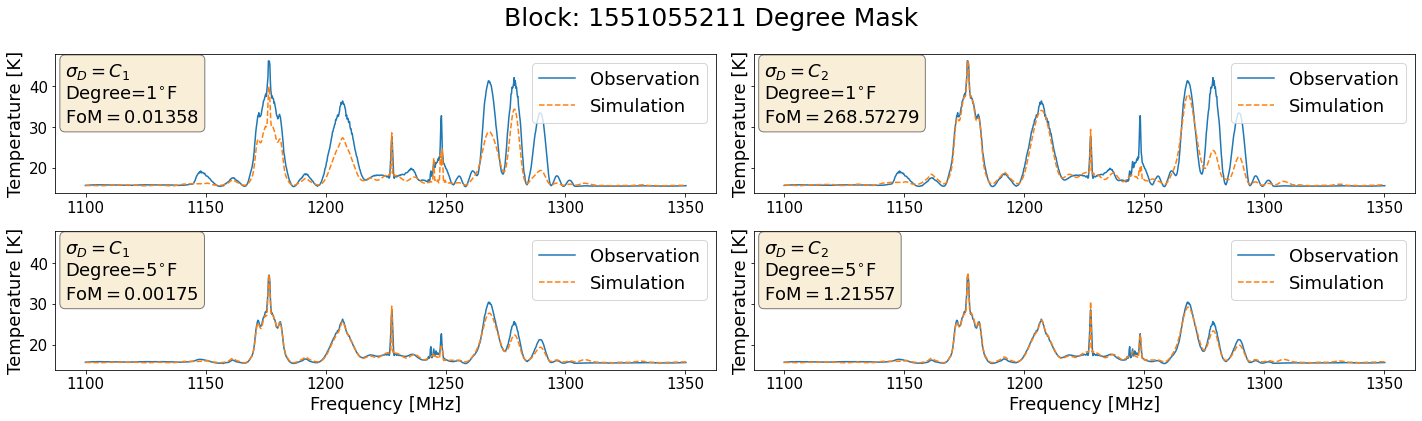

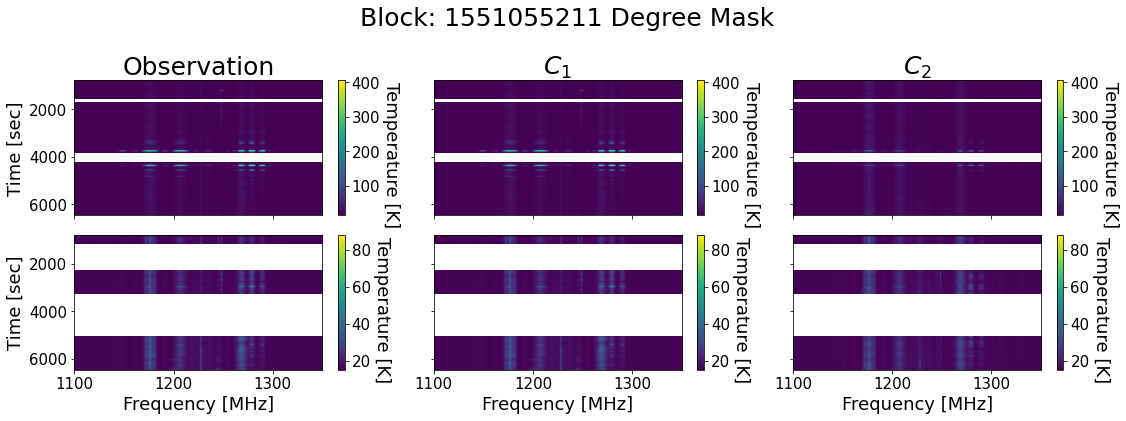

In [27]:
# dictionary with all alpha values per block
angular_mask_dic = {}

for bi in range(len(blocks)):

    # defining degrees to plot (? XXX is it necessary?)
    if blocks[bi] in ['1551055211','1554156377','1556052116','1556138397','1562857793']:
        degree = ['1F', '5F']
        degree_name = [r'$1^{\circ}$F', r'$5^{\circ}$F']
    elif blocks[bi] in ['1553966342','1551037708']:
        degree = ['1F', '2F', '3F', '4F', '5F']
        degree_name = [r'$1^{\circ}$F', r'$2^{\circ}$F', r'$3^{\circ}$F', r'$4^{\circ}$F', r'$5^{\circ}$F']
    
    # retrieving alpha values and adding to the dictionary
    frac, resi = alphas(block_id=blocks[bi], folder_id=folders[bi]+'/degree_mask/')
    angular_mask_dic.update({blocks[bi] : [frac, resi]})
    alpha_plot(frac=frac, resi=resi, block_id=blocks[bi], labels=degree_name, title="Degree", savefig_name='./deg_fitting_alpha.pdf')
    
    # simulation for C1 and C2 values
    md_sf = [chisq_func2(block_id=blocks[bi], a_param=frac[di]['best-fit'],s_param=None, damper=None, sat_info=sat_cat, frequency_slice=[1100, 1350],
                         time_slice=[None,None], t_mask=False, d_mask=deg, time_avg=False, chi_sigma=True, verbose=False)
             for di, deg in enumerate(degree)]
    md_sr = [chisq_func2(block_id=blocks[bi], a_param=resi[di]['best-fit'],s_param=None, damper=None, sat_info=sat_cat, frequency_slice=[1100, 1350],
                         time_slice=[None,None], t_mask=False, d_mask=deg, time_avg=False, chi_sigma=False, verbose=False)
             for di, deg in enumerate(degree)]
    
    # plotting the values
    simulation_1d(frac=md_sf, resi=md_sr, block_id=blocks[bi], labels=degree_name, title="Degree")
    simulation_2d(frac=md_sf, resi=md_sr, block_id=blocks[bi], labels=degree_name, title="Degree", savefig_name='./deg_fitting_waterfall.pdf')
    


### 3. Thermal-masking

This part recovers the figures from Section 4.2.2 (with thermal masking).

Thermal mask: 25 Kelvin.
Thermal mask: 50 Kelvin.
Thermal mask: 100 Kelvin.
Thermal mask: 25 Kelvin.
Thermal mask: 50 Kelvin.
Thermal mask: 100 Kelvin.


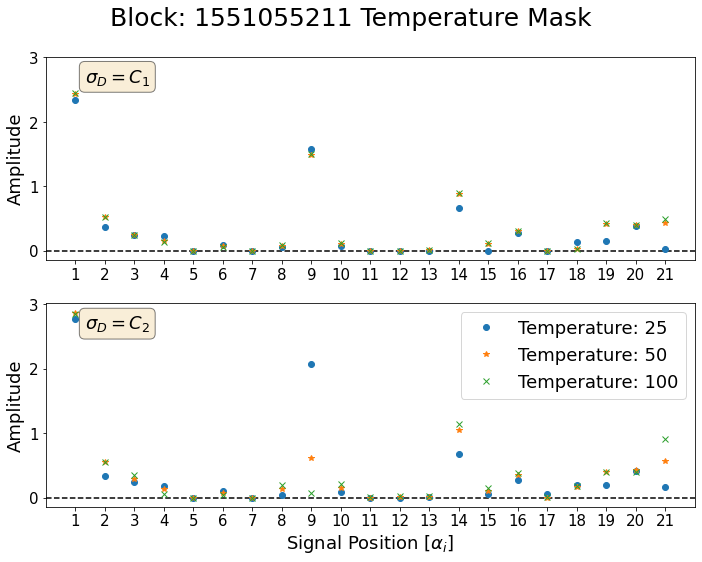

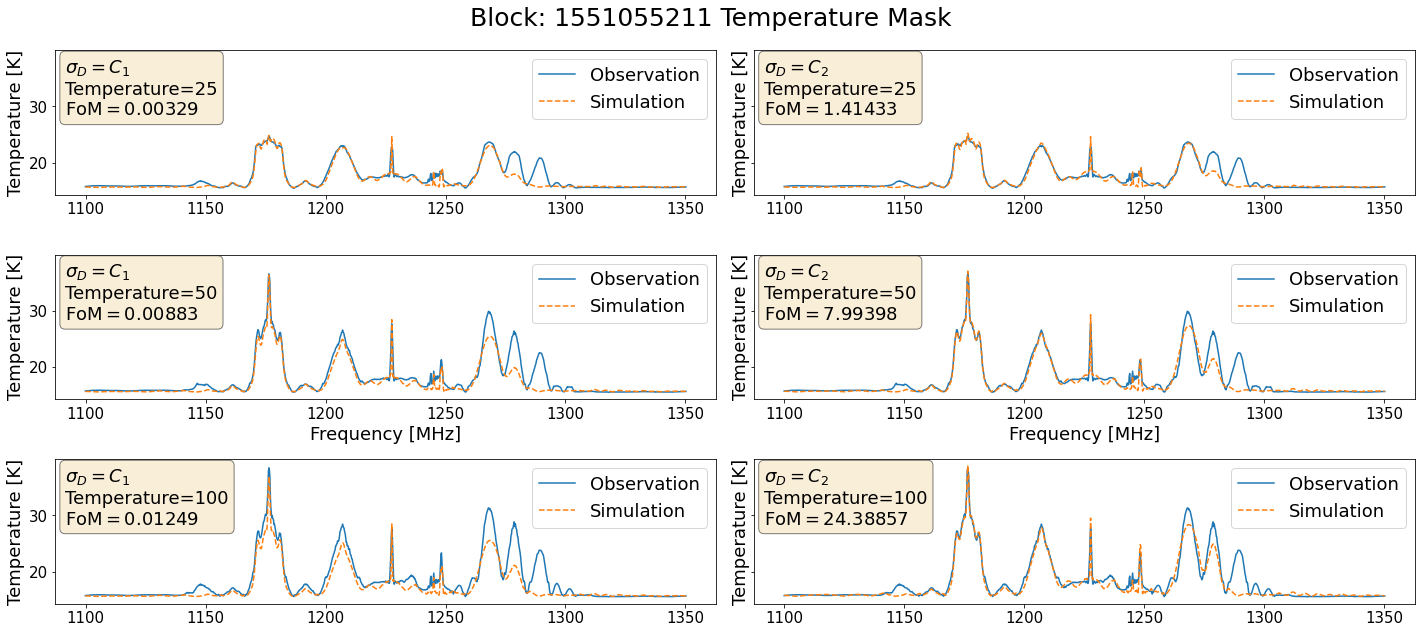

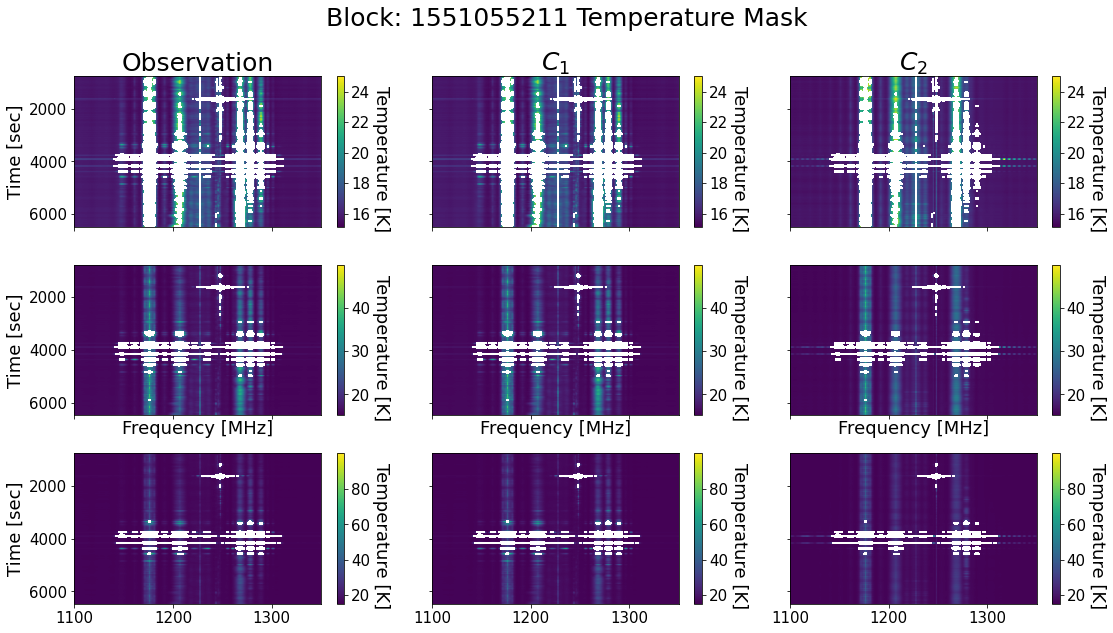

In [34]:
temperature = ['25', '50', '100']
thermal_masking_dic = {}
for bi in range(len(blocks)):
    # Alpha parameters
    frac, resi = alphas(block_id=blocks[bi], folder_id=folders[bi]+'/thermal_mask/')
    thermal_masking_dic.update({blocks[bi] : [frac, resi]})
    alpha_plot(frac=frac, resi=resi, block_id=blocks[bi], labels=temperature, title="Temperature", savefig_name='./thermal2_fitting_alpha.pdf')
    
    #Simulation
    mt_sf = [chisq_func2(block_id=blocks[bi], a_param=frac[ti]['best-fit'], s_param=None, damper=None, frequency_slice=[1100,1350], 
                         time_slice=[None,None], t_mask=int(temp), d_mask=False, time_avg=False, chi_sigma=True, verbose=False)
             for ti,temp in enumerate(temperature)]
  
    mt_sr = [chisq_func2(block_id=blocks[bi], a_param=resi[ti]['best-fit'], s_param=None, damper=None, frequency_slice=[1100,1350], 
                         time_slice=[None,None], t_mask=int(temp), d_mask=False, time_avg=False, chi_sigma=False, verbose=False)
             for ti,temp in enumerate(temperature)]

    # plotting the values
    simulation_1d(frac=mt_sf, resi=mt_sr, block_id=blocks[bi], labels=temperature, title="Temperature")
    simulation_2d(frac=mt_sf, resi=mt_sr, block_id=blocks[bi], labels=temperature, title="Temperature", savefig_name="./thermal_fitting_waterfall.pdf")


### Pixel timeline-masking

In [23]:
def pixel_timeline_alpha(block_id, folder_id):
    '''
    Function to return the fractional and residual alpha values for the pixel timeline mask scenario
    '''
    loc = '/idia/projects/hi_im/satellite_rfi/Testing/' + block_id + '/' + folder_id + '/pixel_timeline_mask/'
    file_list = os.listdir(loc)
    file_list = natsort.natsorted(file_list, key=lambda y: y.lower()) 
    idx = np.arange(len(file_list))
    even_idx = idx[::2]
    odd_idx = idx[1::2]
    
    frac = [
        pickle.load(
        open(
            loc + file_list[di], 'rb'))
               for di in even_idx
           ]
    

    resi = [
        pickle.load(
            open(
                loc + file_list[di], 'rb'))
               for di in odd_idx
    ]
        
    return frac, resi


def pixel_timeline_masking_alpha_plot(frac, resi, block_id, pix_temperature):
    '''
    Pixel timeline masking plot for the temperature alpha 
    '''  
    ls = ['o', '*', 'x', 'o', '*', 'x']
    fig, axs = plt.subplots(figsize=(10, 8), nrows=2, ncols=1, sharey=False)
    fig.suptitle(r'Block: '+block_id+' Pixel Thermal mask')

    
    ax=axs[0]
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xticks(range(1, 21 + 1))
    ax.set_ylabel('Amplitude')

    textstr = '\n'.join((
        r'$\sigma_D=C_1$', ),)
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', bbox=props)

    for pti in range(len(frac)):
        ax.plot(
            np.arange(1,22), frac[pti]['best-fit'], 
            ls[pti], label=r'Temperature: ' + pix_temperature[pti] + ' K')
    ax.axhline(0, color='black', linestyle='--')
    ax.legend(ncol=2)

    
    ax=axs[1]
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xticks(range(1, 21 + 1))
    ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')
    ax.set_ylabel('Amplitude')

    textstr = '\n'.join((
        r'$\sigma_D=C_2$', ),)
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', bbox=props)

    for pti in range(len(resi)):
        ax.plot(
            np.arange(1,22), resi[pti]['best-fit'], 
            ls[pti], label=r'Temperature: ' + pix_temperature[pti] + ' K')        
    ax.axhline(0, color='black', linestyle='--')
    
    
    fig.tight_layout()
    if savegig==True:
        fig.savefig('./pix_timeline_fitting_alpha.pdf')  
    fig.show()
    

    
def pixel_timeline_masking_1d_simulation(frac, resi, block_id, pix_temperature):
    '''
    Function for determining the 1d comparison between the simulation and the model
    '''
    fig, axs = plt.subplots(figsize=(20, 3*len(pix_temperature)), nrows=len(pix_temperature), ncols=2, sharey=False)

    fig.suptitle('Block:'+block_id+' Pixel; Timeline masking')
    for ri in range(len(pix_temperature)):
        ax=axs[ri,0]
        ax.plot(frac[ri][3], np.mean(frac[ri][0], axis=0), label='Observation')
        ax.plot(frac[ri][3], np.mean(frac[ri][1], axis=0), '--', label='Simulation')
        textstr = '\n'.join(
            (
            r'$\sigma_{D}=C_1$',
            r'Px Thermal=' + pix_temperature[ri] + ' K',
            r'FoM$=%.5f$' % (np.round(frac[ri][2], 5), ),)
        )

        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
                verticalalignment='top', bbox=props)
        if ri==2:
            ax.set_xlabel('Frequency [MHz]')
        ax.set_ylabel('Temperature [K]')
        if ri==0:
            ax.legend()
         
        
        
        ax=axs[ri,1]
        ax.plot(resi[ri][3], np.mean(resi[ri][0], axis=0), label='Observation')
        ax.plot(resi[ri][3], np.mean(resi[ri][1], axis=0), '--', label='Simulation')
        textstr = '\n'.join(
            (
            r'$\sigma_{D}=C_2$',
            r'Px Thermal=' + pix_temperature[ri] + ' K',
            r'FoM$=%.2f$' % (np.round(resi[ri][2], 2), ),)
        )

        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
                verticalalignment='top', bbox=props)
        if ri==2:
            ax.set_xlabel('Frequency [MHz]')

    fig.tight_layout()
    if savegig==True:
        fig.savefig('./pix_timeline_fitting.pdf')  
    fig.show()
    
    
def pixel_timeline_masking_2d_simulation(frac, resi, block_id, pix_temperature):
    '''
    Function for plotting the TOD plots
    '''
    
    plots_title = ['Observation', r'$C_1$', r'$C_2$']
    fig, axs = plt.subplots(figsize=(16, 3*len(pix_temperature)), nrows=len(pix_temperature), ncols=3, sharey=True, sharex=True)
    fig.suptitle('Block:'+block_id+' Thermal masking')
    
    for ri in range(len(pix_temperature)):
        for ci in range(3):
                xi = 3*ri+ci
                ax = axs[ri, ci]
                if ri==0:
                    ax.set_title(plots_title[ci])

                if ci==0:
                    cax = ax.imshow(
                        resi[ri][0], 
                        aspect='auto', 
                        extent=[
                            resi[ri][3][0], 
                            resi[ri][3][-1], 
                            pm.nd_s0[-1], 
                            pm.nd_s0[0]
                        ], 
                        vmax=np.max(mpt_sr[ri][0]), 
                        vmin=np.min(mpt_sr[ri][0])
                    )
                    
                elif ci==1:
                    cax = ax.imshow(
                        resi[ri][1], 
                        aspect='auto', 
                        extent=[
                            resi[ri][3][0], 
                            resi[ri][3][-1], 
                            pm.nd_s0[-1], 
                            pm.nd_s0[0]
                        ], 
                        vmax = np.max(mpt_sr[ri][0]), 
                        vmin=np.min(mpt_sr[ri][0])
                    )
                else:
                    cax = ax.imshow(
                        frac[ri][1], 
                        aspect = 'auto', 
                        extent = [
                            resi[ri][3][0], 
                            resi[ri][3][-1], 
                            pm.nd_s0[-1], 
                            pm.nd_s0[0]
                        ], 
                        vmax = np.max(mpt_sr[ri][0]), 
                        vmin = np.min(mpt_sr[ri][0])
                    )  

                cbar = fig.colorbar(cax, ax=ax)
                cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)

                if ci == 0:
                    ax.set_ylabel('Time [sec]')
                if ri == 2:
                    ax.set_xlabel('Frequency [MHz]')

    fig.tight_layout()
    if savegig == True:
        fig.savefig('./pix_timeline_fitting_waterfall.pdf')


6
6
4
6
6
4
6
6
4
6
6
4
6
6
4


IndexError: list index out of range

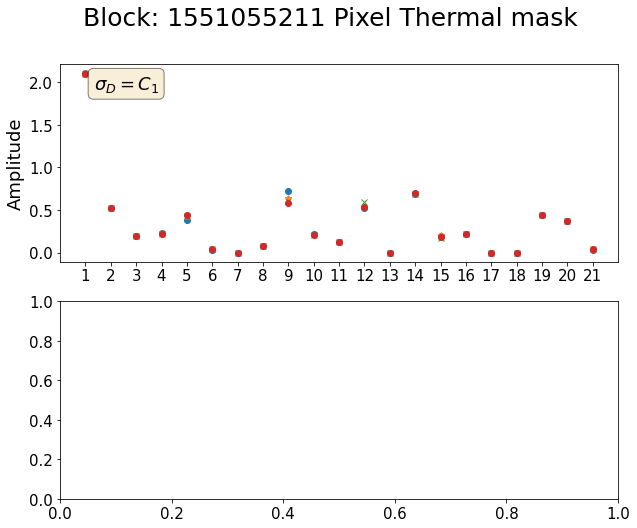

In [22]:
pixel_temperature = ['200', '250', '300', '350']
# pixel_temperature = ['200']

pt_mask_dic = {}
for bi in range(len(blocks)):
    
    # Alpha values
    frac, resi = pixel_timeline_alpha(block_id=blocks[bi], folder_id=folders[bi])
    
    pt_mask_dic.update({blocks[bi] : [frac, resi]})
    
    pixel_timeline_masking_alpha_plot(frac=frac, resi=resi, 
                                      block_id=blocks[bi], pix_temperature=pixel_temperature)

    # Simulation
    mpt_sf = [chisq_func2(
        block_id = blocks[bi], 
        a_param = frac[pti]['best-fit'], 
        s_param = None, 
        damper = None,                  
        frequency_slice = [1100, 1350], 
        time_slice = [None, None], 
        t_mask = False, 
        d_mask = False, 
        pt_mask = int(ptemp),
        time_avg = False, 
        chi_sigma = True, 
        verbose = False
    ) 
             for pti, ptemp in enumerate(pixel_temperature)]
  
    mpt_sr = [chisq_func2(
        block_id = blocks[bi], 
        a_param = resi[pti]['best-fit'], 
        s_param = None, 
        damper = None, 
        frequency_slice = [
            1100, 
            1350
        ], 
        time_slice = [
            None, 
            None
        ], 
        t_mask = False,
        d_mask = False,
        pt_mask = int(ptemp),
        time_avg = False, 
        chi_sigma = False, 
        verbose = False
    ) 
             for pti, ptemp in enumerate(pixel_temperature)]
    
    
    
    pixel_timeline_masking_1d_simulation(
        frac = mpt_sf,
        resi = mpt_sr, 
        block_id = blocks[bi],
        pix_temperature = pixel_temperature
    )
    
    pixel_timeline_masking_2d_simulation(
        frac = mpt_sf,
        resi = mpt_sr, 
        block_id = blocks[bi],
        pix_temperature = pixel_temperature
    )

### Temporal-masking

In [14]:
def temporal_masking_alpha(block_id, folder_id):
    loc = '/idia/projects/hi_im/satellite_rfi/Testing/'+block_id+'/'+folder_id+'/time_zones/'
    
    if block_id == str(1551055211):
        ts = [775, 2200, 5500]
        te = [1000, 2400, 6200]        
        
    elif block_id == str(1562857793):
        ts = [986, 1868, 2338, 4815]
        te = [1850, 2257, 3223, 6689]
        
    elif block_id == str(1556138397):
        ts = [936, 2183]
        te = [1296, 6634]
        
    elif block_id == str(1556052116):
        ts = [1102, 1724, 5404]
        te = [1225, 4462, 6673]
        
    elif block_id == str(1554156377):
        ts=[938, 2617]
        te=[1365, 6641]
        
    elif block_id == str(1553966342):
        ts=[1005.5]
        te=[4505]
        
    elif block_id == str(1551037708):
        ts=[737.175, 1762.75, 4625.55]
        te=[1756, 3543.9, 6440.7]
        
        # ts=[851, 3543]
        # te=[1757, 4623.55]
    else:
        print ('Check block')
    
    time_zone = [str(ts[ti]) + '-' + str(te[ti]) for ti in range(len(ts))]

    file_list = os.listdir(loc)
    file_list.sort()

    file_list_s = [] 
    for tsi in ts:
        for fl in file_list:
            if str(tsi) in fl:
                file_list_s.append(fl)

    idx = np.arange(len(file_list_s))
    even_idx = idx[::2]
    odd_idx = idx[1::2]

    frac = [pickle.load(
        open(
            loc+file_list_s[di],'rb'
        )
    )
               for di in even_idx]

    resi = [pickle.load(
        open(
            loc+file_list_s[di],'rb'
        )
    )
               for di in odd_idx]
    
    return frac, resi, time_zone, ts, te

def temporal_masking_alpha_plot(frac, resi, time_start, time_end, time_zone, block_id):
    '''
    Function for plotting the alpha values for the temporal masking scenario
    '''
    ls = ['o', 'x']
    fig, axs = plt.subplots(figsize=(10, len(time_start)*4), nrows=len(time_start), ncols=1, sharex=True, sharey=True)
    fig.suptitle(r'Block: '+block_id+' Temporal Alpha')

    for ri in range(len(time_start)):
        if len(time_start)>1:
            ax=axs[ri]
        else:
            ax=axs
        textstr = '\n'.join((
            r'Time zone: '+str(time_zone[ri])+' sec', ),)

        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        # place a text box in upper left in axes coords
        ax.text(0.06, 0.95, textstr, transform=ax.transAxes, fontsize=18,
                verticalalignment='top', bbox=props)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.set_xticks(range(1, 21 + 1))
        ax.set_ylabel('Amplitude')
        ax.plot(np.arange(1,22), frac[ri]['best-fit'], ls[0], alpha=0.6, label=r'$\chi_{\sigma}$=$C_2$')
        ax.plot(np.arange(1,22), resi[ri]['best-fit'], ls[1], label=r'$\chi_{\sigma}=C_1$')
        ax.axhline(0, linestyle='--', color='k')
        if ri==len(ts):
            ax.set_xlabel(r'Signal Position $[\alpha_{i}]$')
        if ri==0:
            ax.legend(loc='best')

    fig.tight_layout()
    if savegig==True:
        fig.savefig('./temporal_fitting_alpha.pdf')

    fig.show()
    
def temporal_masking_1d_simulation(frac, resi, time_start, time_end, time_zone, block_id):
    fig, axs = plt.subplots(figsize=(20, 3*len(ts)), nrows=len(time_start), ncols=2, sharey=True)
    fig.suptitle(r'Block: '+block_id+' Temporal Masking')

    for ri in range(len(time_start)):
        if len(time_start)>1:
            ax=axs[ri,0]
        else:
            ax=axs[0]
        ax.plot(frac[ri][3], np.ma.mean(frac[ri][0], axis=0), label='Observation')
        ax.plot(frac[ri][3], np.ma.mean(frac[ri][1], axis=0), '--', label='Simulation')
        textstr = '\n'.join((
            r'$\sigma_D=C_1$',
            r'Time='+time_zone[ri]+' sec',
            r'FoM$=%.5f$' % (np.round(frac[ri][2], 5), ),))

        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
                verticalalignment='top', bbox=props)

        if ri==len(ts):
            ax.set_xlabel('Frequency [MHz]')
        ax.set_ylabel('Temperature [K]')
        if ri==0:
            ax.legend()

        if len(time_start)>1:
            ax=axs[ri,1]
        else:
            ax=axs[1]
        ax.plot(resi[ri][3], np.ma.mean(resi[ri][0], axis=0), label='Observation')
        ax.plot(resi[ri][3], np.ma.mean(resi[ri][1], axis=0), '--', label='Simulation')
        textstr = '\n'.join((
            r'$\sigma_D=C_2$',
            r'Time='+time_zone[ri]+' sec',
            r'FoM$=%.2f$' % (np.round(resi[ri][2], 2), ),))

        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
                verticalalignment='top', bbox=props)

        if ri==len(ts):
            ax.set_xlabel('Frequency [MHz]')

    fig.tight_layout()
    if savegig==True:
        fig.savefig('./temporal_fitting.pdf')

    fig.show()
    
def temporal_masking_2d_simulation(frac, resi, time_start, time_end, time_zone, block_id):
    plots_title = ['Observation', r'$C_1$', r'$C_2$']
    
    fig, axs = plt.subplots(
        figsize=(16, 3*len(time_start)), 
        nrows=len(time_start), 
        ncols=3, 
        sharey=False, 
        sharex=True
    )
    
    fig.suptitle(r'Block: ' + block_id + ' Temporal Masking')
    for ri in range(len(time_start)):
        for ci in range(3):
            xi = 3*ri+ci
            if len(time_start)>1:
                ax = axs[ri, ci]
            else:
                ax = axs[ci]
            if ri == 0:
                ax.set_title(plots_title[ci])
            if ci == 0:
                cax = ax.imshow(
                    resi[ri][0], 
                    aspect='auto', 
                    extent=[
                        resi[ri][3][0], 
                        resi[ri][3][-1], 
                        time_end[ri], 
                        time_start[ri]
                    ], 
                    vmax=np.max(mtz_sr[ri][0]), 
                    vmin=np.min(mtz_sr[ri][0])
                )
                
            elif ci == 1:
                cax = ax.imshow(
                    frac[ri][1], 
                    aspect='auto', 
                    extent=[
                        resi[ri][3][0], 
                        resi[ri][3][-1], 
                        time_end[ri], 
                        time_start[ri]
                    ], 
                    vmax=np.max(mtz_sr[ri][0]), 
                    vmin=np.min(mtz_sr[ri][0])
                )
                
            else:
                cax = ax.imshow(
                    resi[ri][1], 
                    aspect='auto', 
                    extent=[
                        resi[ri][3][0], 
                        resi[ri][3][-1], 
                        time_end[ri], 
                        time_start[ri]
                    ], 
                    vmax=np.max(mtz_sr[ri][0]), 
                    vmin=np.min(mtz_sr[ri][0])
                )
                
            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)

            if ci == 0:
                ax.set_ylabel('Time [sec]')
            if ri == 2:
                ax.set_xlabel('Frequency [MHz]')

    fig.tight_layout()
    if savegig == True:
        fig.savefig('./temporal_fitting_waterfall.pdf')
        
    fig.show()

No masking applied
No masking applied
No masking applied
No masking applied
No masking applied
No masking applied


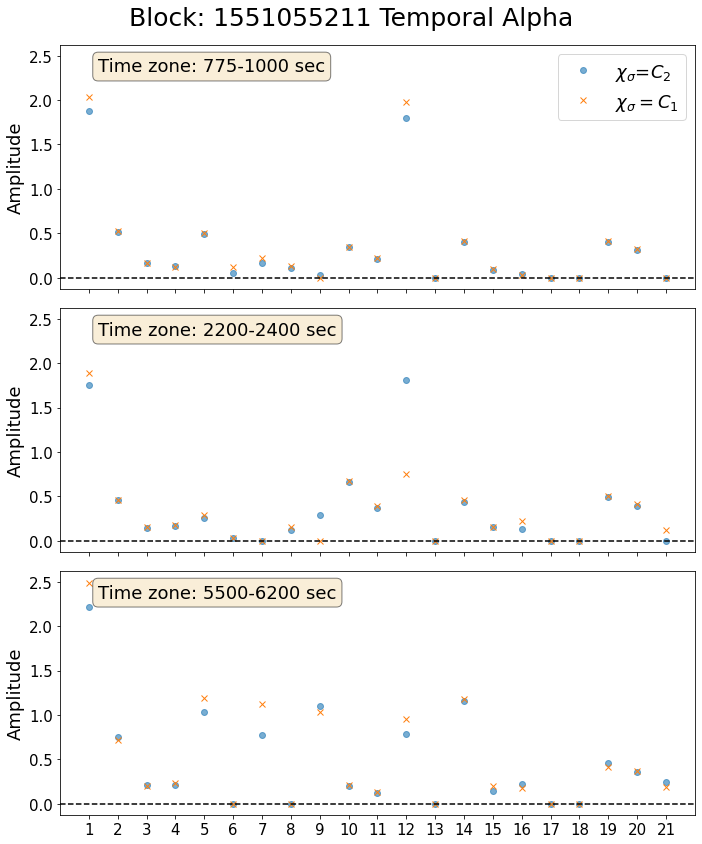

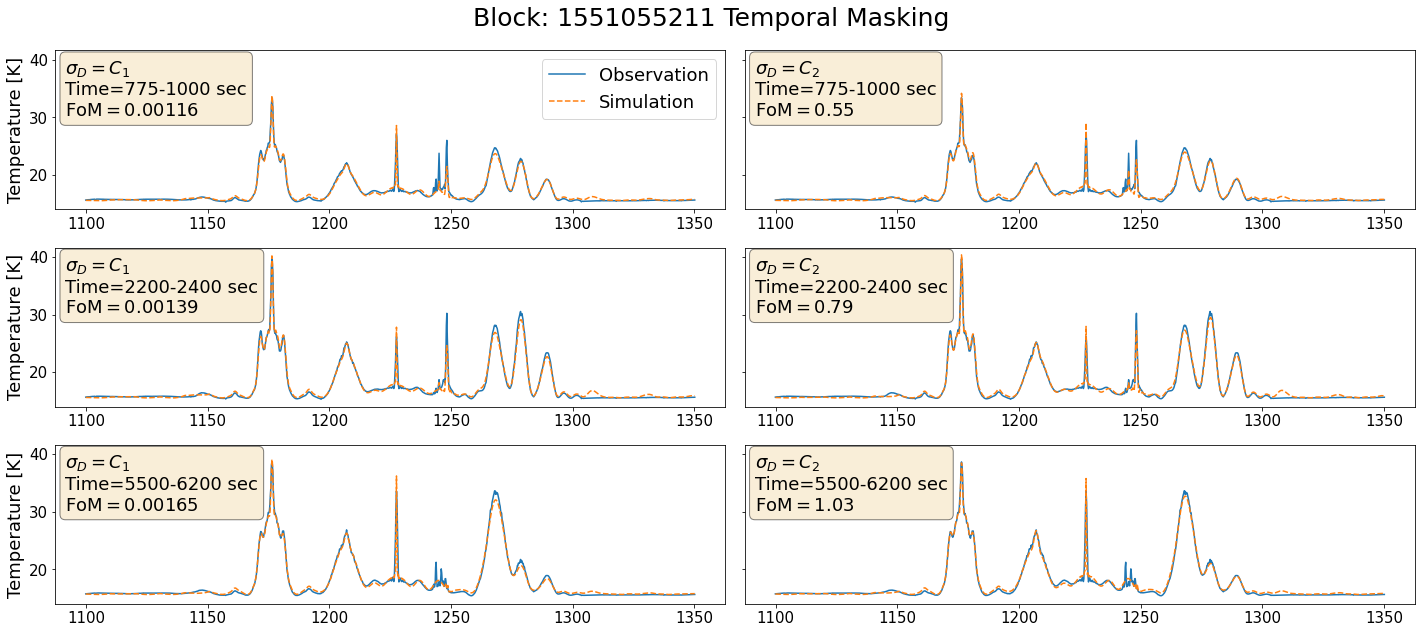

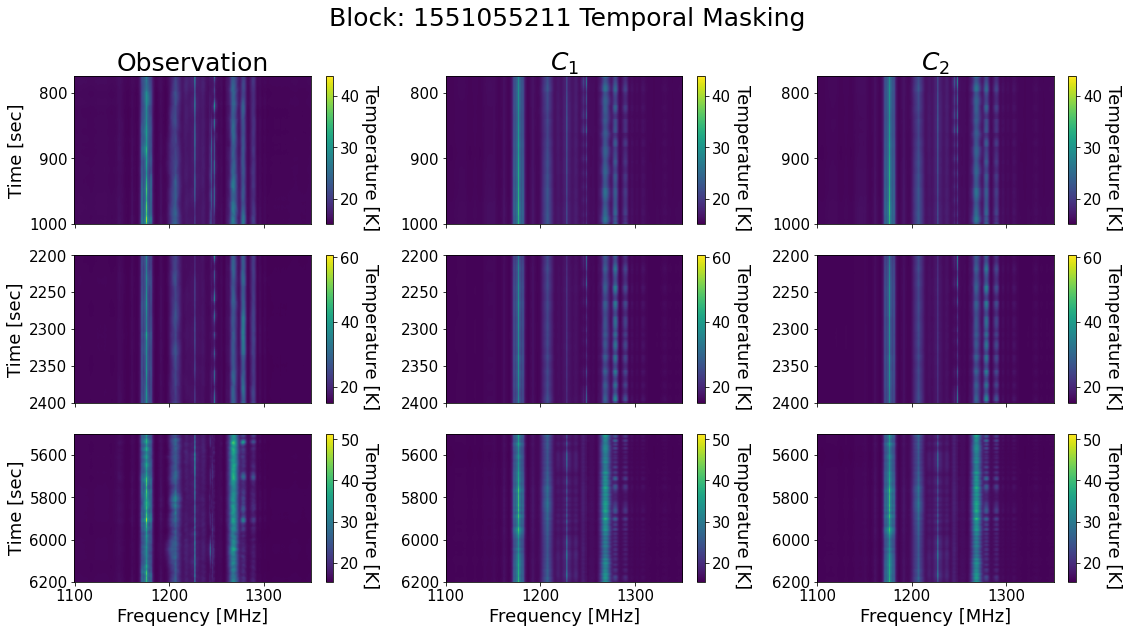

In [15]:
temporal_masking_dic = {}
for bi in range(len(blocks)):
    # Alpha parameters
    frac, resi, time_zone, ts, te = temporal_masking_alpha(
        block_id = blocks[bi], 
        folder_id = folders[bi]
    )
    
    temporal_masking_dic.update({blocks[bi] : [frac, resi]})
    temporal_masking_alpha_plot(
        frac = frac, 
        resi = resi, 
        time_start = ts, 
        time_end = te, 
        time_zone = time_zone, 
        block_id = blocks[bi]
    )
    
    # Simulation
    
    mtz_sf = [chisq_func2(
        block_id = blocks[bi],
        a_param = frac[tz]['best-fit'],
        s_param = None,
        damper = None,
        frequency_slice = [
            1100, 
            1350
        ], 
        time_slice = [
            ts[tz],
            te[tz]
        ], 
        t_mask = False,
        d_mask = False,
        time_avg = False, 
        chi_sigma = True, 
        verbose = False
    ) for tz,time in enumerate(time_zone)
             ]

    mtz_sr = [chisq_func2(
        block_id = blocks[bi],
        a_param = resi[tz]['best-fit'],
        s_param = None,
        damper = None,
        frequency_slice = [
            1100, 
            1350
        ], 
        time_slice = [
            ts[tz],
            te[tz]
        ], 
        t_mask = False,
        d_mask = False,
        time_avg = False, 
        chi_sigma = False,
        verbose = False
    ) for tz,time in enumerate(time_zone)
             ]
    
    
    temporal_masking_1d_simulation(
        frac = mtz_sf,
        resi = mtz_sr,
        time_start = ts,
        time_end = te,
        time_zone = time_zone,
        block_id = blocks[bi]
    )
    
    temporal_masking_2d_simulation(
        frac = mtz_sf,
        resi = mtz_sr,
        time_start = ts,
        time_end = te,
        time_zone = time_zone,
        block_id = blocks[bi]
    )
    

### Temporal-masking + Coarse grain

In [16]:
def temporal_masking_coarse_alpha(block_id, folder_id):
    loc = '/idia/projects/hi_im/satellite_rfi/Testing/'+block_id+'/'+folder_id+'/time_average/'
    
    if block_id==str(1551055211):
        ts = [775, 2200, 5500]
        te = [1000, 2400, 6200]        
    elif block_id==str(1562857793):
        ts = [986, 1868, 2338, 4815]
        te = [1850, 2257, 3223, 6689]    
    elif block_id==str(1556138397):
        ts = [936, 2183]
        te = [1296, 6634]
    elif block_id==str(1556052116):
        ts = [1102, 1724, 5404]
        te = [1225, 4462, 6673]
    elif block_id==str(1554156377):
        ts=[938, 2617]
        te=[1365, 6641]
    elif block_id==str(1553966342):
        ts=[1005.5]
        te=[4505]
    elif block_id==str(1551037708):
        ts=[737.175, 1762.75, 4625.55]
        te=[1756, 3543.9, 6440.7]

    else:
        print ('Check block')
    
    time_zone = [str(ts[ti])+'-'+str(te[ti]) for ti in range(len(ts))]

    file_list = os.listdir(loc)
    file_list.sort()

    file_list_s = [] 
    for tsi in ts:
        for fl in file_list:
            if str(tsi) in fl:
                file_list_s.append(fl)

    idx = np.arange(len(file_list_s))
    even_idx = idx[::2]
    odd_idx = idx[1::2]

    frac = [pickle.load(open(loc+file_list_s[di],'rb'))
               for di in even_idx]

    resi = [pickle.load(open(loc+file_list_s[di],'rb'))
               for di in odd_idx]
    
    return frac, resi, time_zone, ts, te


def temporal_masking_coarse_1d_simulation(frac, time_start, time_end, time_zone, block_id):
    fig, axs = plt.subplots(figsize=(20, 4*len(time_start)), nrows=len(time_start), ncols=1, sharey=True)

    fig.suptitle(r'Block: '+block_id+' Temporal masking & coarse grain')
    for ri in range(len(time_start)):
        if len(time_start)>1:
            ax=axs[ri]
        else:
            ax=axs
        ax.plot(frac[ri][3], np.ma.mean(frac[ri][0], axis=0), label='Observation')
        ax.plot(frac[ri][3], np.ma.mean(frac[ri][1], axis=0), '--', label='Simulation')
        textstr = '\n'.join((
            r'$\sigma_D=C_1$',
            r'Time='+time_zone[ri]+' sec',
            r'$\chi^2/N=%.5f$' % (np.round(frac[ri][2], 5), ),))

        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18,
                verticalalignment='top', bbox=props)

        if ri==len(ts):
            ax.set_xlabel('Frequency [MHz]')
        ax.set_ylabel('Temperature [K]')
        ax.legend()
        fig.tight_layout()
        # fig.savefig('./temporal2_fitting.pdf')

        fig.show()
        
def temporal_masking_coarse_2d_simulation(frac, time_start, time_end, time_zone, block_id):
    plots_title = ['Observation', r'$C_1$']
    fig, axs = plt.subplots(figsize=(16, 3*len(time_start)), nrows=len(time_start), ncols=2, sharex=True)
    fig.suptitle(r'Block: '+block_id+' Temporal masking & coarse grain')
    for ri in range(len(time_start)):
        for ci in range(2):
            xi = 3*ri+ci
            if len(time_start)>1:
                ax = axs[ri, ci]
            else:
                ax = axs[ci]
            if ri==0:
                ax.set_title(plots_title[ci])
            if ci==0:
                cax = ax.imshow(mtza_sf[ri][0], aspect='auto', extent=[f_slice[0], f_slice[-1], te[ri], ts[ri]], vmax=np.max(mtz_sf[ri][0]), vmin=np.min(mtz_sf[ri][0]))
            elif ci==1:
                cax = ax.imshow(mtza_sf[ri][1], aspect='auto', extent=[f_slice[0], f_slice[-1], te[ri], ts[ri]], vmax=np.max(mtz_sr[ri][0]), vmin=np.min(mtz_sr[ri][0]))  

            cbar = fig.colorbar(cax, ax=ax)
            cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)

            if ci==0:
                ax.set_ylabel('Time [sec]')
            if ri==2:
                ax.set_xlabel('Frequency [MHz]')

    fig.tight_layout()
    # fig.savefig('./temporal2_fitting_waterfall.pdf')
    
    fig.show()


No masking applied
Time averageing for every 10 seconds
No masking applied
Time averageing for every 10 seconds
No masking applied
Time averageing for every 10 seconds


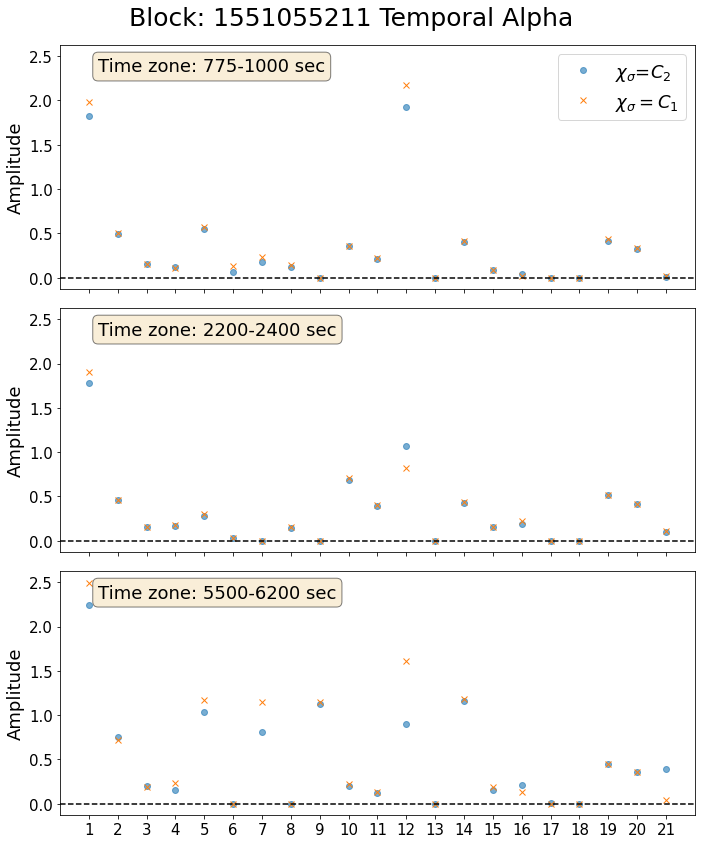

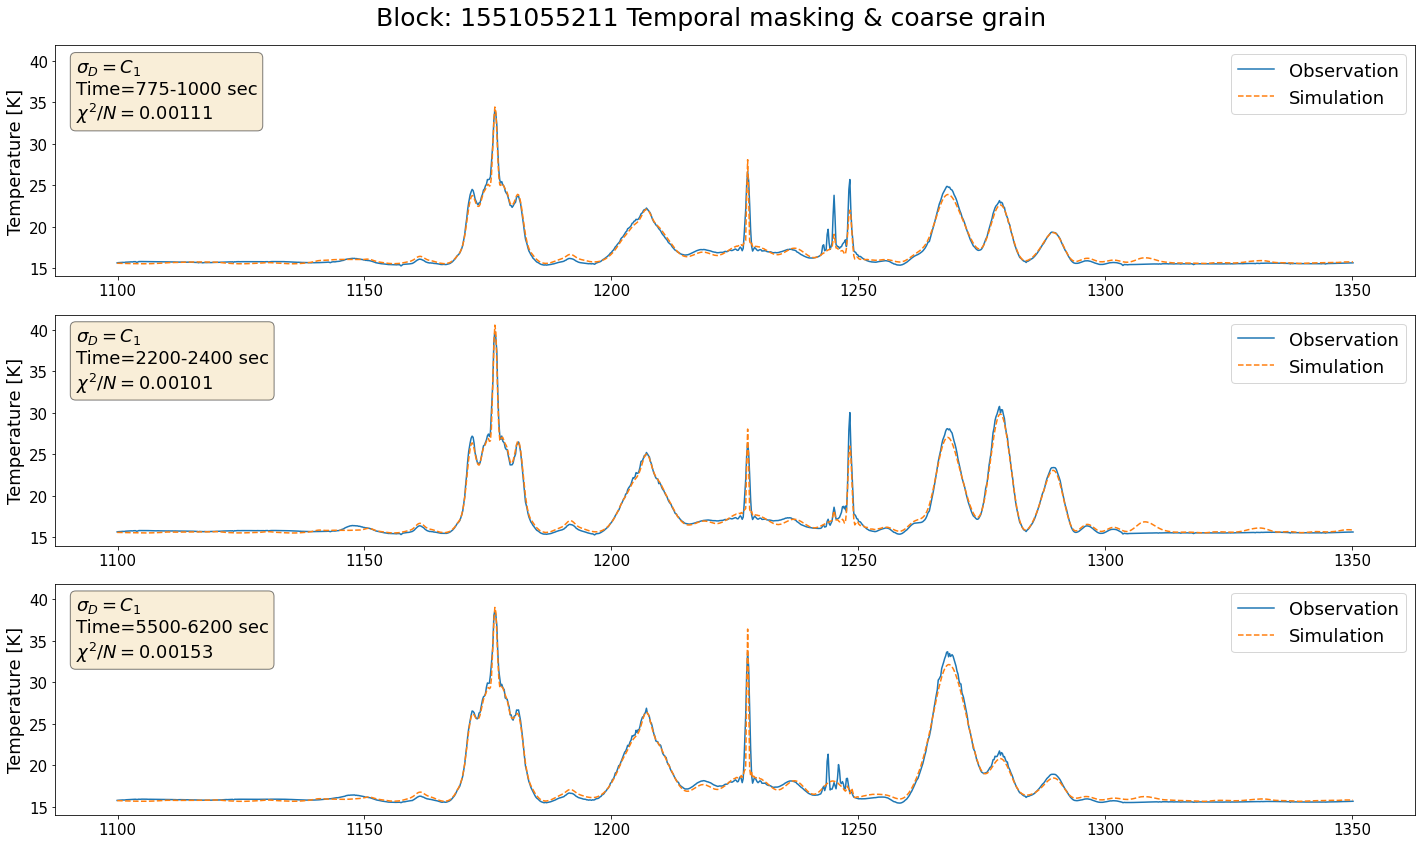

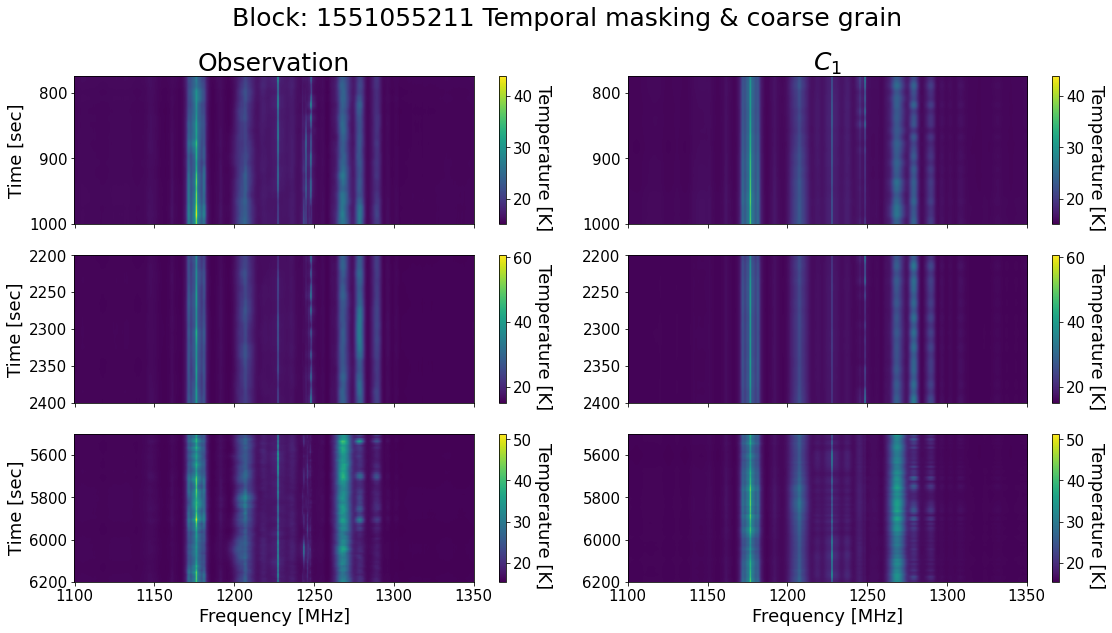

In [17]:
temporal_masking_coarse_dic = {}
for bi in range(len(blocks)):
    # Alpha parameters
    frac, resi, time_zone, ts, te = temporal_masking_coarse_alpha(block_id=blocks[bi], folder_id=folders[bi])
    temporal_masking_coarse_dic.update({blocks[bi] : [frac, resi]})
    temporal_masking_alpha_plot(frac=frac, resi=resi, time_start=ts, time_end=te, time_zone=time_zone, block_id=blocks[bi])
    
    mtza_sf = [chisq_func2(block_id=blocks[bi],a_param=frac[tz]['best-fit'], s_param=None, damper=None, frequency_slice=[1100, 1350], time_slice=[ts[tz], te[tz]], 
                     t_mask=False, d_mask=False ,time_avg=10, chi_sigma=True, verbose=False) for tz,time in enumerate(time_zone)]
    
    temporal_masking_coarse_1d_simulation(frac=mtza_sf, time_start=ts, time_end=te, time_zone=time_zone, block_id=blocks[bi])
    temporal_masking_coarse_2d_simulation(frac=mtza_sf, time_start=ts, time_end=te, time_zone=time_zone, block_id=blocks[bi])

In [ ]:
stop

## Running for the extended frequency range

Code for running the data without the background model

Note that the 2d angular satellite maps should be in the correct frequency range.

Note that the frequency range should be further than the length set

Once you set the number of satellites you cannot increase or decrease the satellite information. Have to keep the same length of satellites

In [ ]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

In [ ]:
def chisq_func3(block_id, a_param, s_param=None, damper=None, satellites_only=True, 
                sat_info=pm.satellite_catalogue, add_sub=[False, True],
                frequency_slice=False, time_slice=False, t_mask=False, d_mask=False, time_avg=False, verbose=False):
    
    data_save='/idia/projects/hi_im/satellite_rfi/Testing/'+block_id+'/'
    # Needed this function to update the data information
    nd_s0, nd_s0_coords, nd_s0_coords2, nd_s0_pos, frequency = katdal_information(data_save=data_save+block_id)
    
    if d_mask==False:
        satellites=None
    else:
        satellites=pm.data_save+'nearby_satellites/nearby_satellite_close_angle_'+d_mask+'.p'
    
    """INITIALIZING THE SATELLITE FUNCTION"""
    sat = ss(file_name=block_id, 
                 sats_only=satellites_only, 
                 data_loc=data_save, 
                 sat_loc=data_save,
                 survey_info=[nd_s0, nd_s0_coords, frequency], 
                 sat_info=sat_info,
                 plots_loc=data_save,
                 sat_beam=pm.beam_model+'_beam_'+str(950)+'_'+str(1500)+'MHz', 
                 frequency_range=[950, 1500], 
                 constellations=pm.constellations_remain,
                 nearby_satellites=satellites,
                 verbose=False)
        
    """EXCECUTING THE THE SATELLITE SIM FUNCTION"""
    sat.excecute(a_param=a_param, 
                 obs_time_start=time_slice[0], obs_time_end=time_slice[1], 
                 obs_frequency_start=frequency_slice[0], obs_frequency_end=frequency_slice[1], 
                 file_bias_choice=pm.bias, 
                 add_sub=[add_sub[0], add_sub[1]], 
                 attenuation_func=damper, 
                 attenuation_sigma=s_param, 
                 bandsize=None,
                 verbose=False)

    """FREQUENCY SLICE"""
    frange_slice = sat.frequency_band[sat.frequency_idx[0]:sat.frequency_idx[1]]  
    if satellites_only==False:
        """MASKING"""
        ## TEMPERATURE MASKING 
        if t_mask!=False and d_mask==False:
            print ('Temperature mask of '+str(t_mask)+' Kelvin')
            zero_arr = np.zeros(sat.calibration_data_slice.shape)
            mask_idx = np.where(sat.calibration_data_slice > t_mask)

            zero_arr[mask_idx]=1
            simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=zero_arr.T)    #SIMULATIONS
            data = np.ma.array(data=sat.calibration_data_slice.T, mask=zero_arr.T)  #DATA

        ## DEGREE MASKING
        elif d_mask!=False and t_mask==False:
            print ("Area mask of "+str(d_mask)+" degrees")
            simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=sat.mask_nearby_satellites_slice)
            data = np.ma.array(data=sat.calibration_data_slice.T, mask=sat.mask_nearby_satellites_slice)

        ## NO MASKING
        else:
            print ("No masking applied")
            simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=None)
            data = np.ma.array(data=sat.calibration_data_slice.T, mask=None)
        return data, simulation, frange_slice#, sat.sat_data_adjusted
    else:
        if d_mask!=False:
            print ('Masking and Satellites Only')
            simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=sat.mask_nearby_satellites_slice)
        else:
            print ("No masking and Satellites Only")
            simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=None)
        return simulation, frange_slice, nd_s0, nd_s0_pos#, sat.sat_data_adjusted        
        


    

In [ ]:
def residual_level4_maps(block_id, antenna_no):
    '''
    Function to obtain the resiuald map from the data set that Mel gave.
    The data is tored at the same location 
    Parameters: 
        block_id - the block/file number
        antanna_no - the antenna number is in use
    '''
    
    hh4 = pickle.load(open('/users/bengelbrecht/Tresid_'+block_id+'_'+antenna_no+'h_l4masks', 'rb'), encoding='latin1')
    vv4 = pickle.load(open('/users/bengelbrecht/Tresid_'+block_id+'_'+antenna_no+'v_l4masks', 'rb'), encoding='latin1')
    
    return hh4, vv4

# Obtaining the frequecny index information for the start and end. This is based on the fact that eah block as the same frequency information
fs, fe = tools.find_idx(data_array=pm.frequency, data_variable=973), tools.find_idx(data_array=pm.frequency, data_variable=1015.2)

def extended_cosmo_band_2d(block_id, data_info, data_info_name, frequency, time):
    fig, axs = plt.subplots(figsize=(6*len(data_info),6), nrows=1, ncols=len(data_info))
    fig.suptitle('Block: '+block_id+' Data vs Model comparison')
    
    for di in range(len(data_info)):
        ax=axs[di]
        ax.set_title(data_info_name[di])
        ax.set_title(data_info_name[di])
        cax = ax.imshow((data_info[di]), aspect='auto', extent=[frequency[0], frequency[1], time[0], time[-1]]) 
        cbar = fig.colorbar(cax, ax=ax)
        cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20, y=0.45)
        ax.set_xlabel('Frequency [MHz]')
        ax.set_ylabel('Time [sec]')
        
    fig.tight_layout()
    fig.show()
    

def extended_cosmo_band_1d_plot(block_id, flist, data_info, data_info_name, time):
    '''
    Function for frequency response in the cosmological band, only six frequency indices should be selected
    '''
    fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(16, 8), sharey=True, sharex=True)
    fig.suptitle('Block: '+block_id+' 1D frequency comparison')
    for ri in range(2):
        for ci in range(3):
            x = 3*ri+ci
            ax = axs[ri,ci]
            
            for di in range(len(data_info)):
                ax.plot(time, data_info[di][:, flist[x]], alpha=1-0.3*di, label=data_info_name[di])

                
            if ci==0:
                ax.set_ylabel('Temperature [K]')
            if ri==1:
                ax.set_xlabel('Time [sec]')

            textstr = '\n'.join((
                r'$\nu$: '+str(frange_reduced[flist[x]])+' MHz',))

            props = dict(boxstyle='round', facecolor='wheat', alpha=0.2)
            # place a text box in upper left in axes coords
            ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=14,
                    verticalalignment='top', bbox=props)

            if x==4:
                ax.legend(ncol=3, frameon=True, loc='lower center', fontsize=14)
            

    fig.tight_layout()
    if savegig==True:
        fig.savefig('./cosmological_band.pdf')
    fig.show()
    
def rmsValue(arr):
    '''
    Function that produces the root mean sqaure of an array
    Parameters: 
        arr - array of values
    Return 
        RMS
    '''
    # Mean of the array
    arr_mean = np.ma.mean(arr)
    # getting the length of the array
    n = float(len(arr))
    #Calculate square
    square = np.ma.sum((arr-arr_mean)**2) /  float(n)
    #Calculate Root
    root = np.ma.sqrt(square)
     
    return root

def rms_values_cosmo_band(block_id, frequency, hhpol, vvpol, model):
    fig, axs = plt.subplots(figsize=(16, 4), nrows=1, ncols=2, sharey=True)
    fig.suptitle('Block: '+block_id+' RMS calculation')
    ax=axs[0]
    ax.plot(frequency, hhpol[1], '.', label='Flag:Lvl 4')
    ax.plot(frequency, hhpol[2], '.', label='Flag:Lvl 4 + 5F ')
    ax.plot(frequency, model[0], '.', label='Sim:Lvl 4 + 5F ')
    ax.legend(loc='upper right', fontsize=15)
    ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('RMS')
    ax.set_title('RMS for HH-pol')
    
    ax=axs[1]
    ax.plot(frequency, vvpol[1], '.', label='Flag:Lvl 4')
    ax.plot(frequency, vvpol[2], '.', label='Flag:Lvl 4 + 5F ')
    ax.plot(frequency, model[0], '.', label='Sim:Lvl 4 + 5F ')
    ax.legend(loc='upper right', fontsize=15)
    ax.set_xlabel('Frequency [MHz]')
    ax.set_title('RMS for VV-pol')    
    fig.tight_layout()
    # if savegig==True:
        # fig.savefig('./temporal_fitting_residual_ang.pdf')
    fig.show()
    
def rms_values_cosmo_band_total(block_id, frequency, pol, model):
    fig, axs = plt.subplots(figsize=(16, 4), nrows=1, ncols=1, sharey=True)
    ax=axs
    ax.plot(frequency, pol[1], '.', label='Flag:Lvl 4')
    ax.plot(frequency, pol[2], '.', label='Flag:Lvl 4 + 5F ')
    ax.plot(frequency, model[0], '.', label='Sim:Lvl 4 + 5F ')
    ax.legend(loc='upper right', fontsize=15)
    ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('RMS')
    ax.set_title('Block: '+block_id+' RMS for (HH+VV)/2')

    # if savegig==True:
        # fig.savefig('./temporal_fitting_residual_ang.pdf')
    fig.show()


In [ ]:
alpha_choice = [0,0,0,0,1,1,0]
degree_masking_type = ['3F', '5F', '5F', '5F', '5F', '5F', '5F']
thermal_masking_type = [False, False, False, False, False, False, False]

In [ ]:
rms_hh_val, rms_vv_val, rms_hhvv_val, rms_model_val = [], [], [], []

for ei in range(len(blocks)):
    # Note the codes needs the frequency range to extend beyond the central frequencies within the data
    #     sim_ext, frange_ext, nd_s0, nd_s0_pos = chisq_func3(block_id=blocks[ei], a_param=frac[1]['best-fit'], s_param=None, damper=None, 
    #                                       frequency_slice=[973, 1350], time_slice=[None, None], t_mask=50, d_mask=False ,time_avg=False, verbose=False)
    
    sim_ext, frange_ext, nd_s0, nd_s0_pos = chisq_func3(block_id=blocks[ei], 
                                                        a_param=temporal_masking_dic[blocks[ei]][0][alpha_choice[ei]]['best-fit'],
                                                        s_param=None, damper=None,frequency_slice=[973, 1350], time_slice=[None, None], 
                                                        t_mask=thermal_masking_type[ei], d_mask=degree_masking_type[ei],
                                                        time_avg=False, verbose=False)


    # Obtaining the residual information for the level 4 information of the various blocks
    if blocks[ei]=='1551055211' or blocks[ei]=='1556052116' or blocks[ei]=='1556138397' or\
    blocks[ei]=='1551037708' or blocks[ei]=='1553966342' or blocks[ei]=='1554156377':
        ant_no='m000'
    if blocks[ei]=='1562857793':
        ant_no='m004'

    print (blocks[ei])
    print (ant_no)
    print (alpha_choice[ei])
    print (degree_masking_type[ei])
    print (thermal_masking_type[ei])   

    resi_hh4, resi_vv4 = residual_level4_maps(block_id=blocks[ei], antenna_no=ant_no)
    resi_hhvv4 = (resi_hh4+resi_vv4)/2

    # Obtaining the reduced frequency range to match the cosmological banf inforation
    fend_idx = np.where(frange_ext>1015)[0][0]
    frange_reduced = frange_ext[:fend_idx]
    sim_e_reduced = sim_ext[:, :fend_idx]

    # Reducing the size of the level 4 residual and masking it similar to that of the extended simulation 
    resi_hh4_2 = resi_hh4[nd_s0_pos, fs:fe][:-1, :]
    resi_hh4_2m = np.ma.array(data=resi_hh4_2, mask=sim_e_reduced.mask)

    resi_vv4_2 = resi_vv4[nd_s0_pos, fs:fe][:-1, :]
    resi_vv4_2m = np.ma.array(data=resi_vv4_2, mask=sim_e_reduced.mask)

    resi_hhvv4_2 = resi_hhvv4[nd_s0_pos, fs:fe][:-1, :]
    resi_hhvv4_2m = np.ma.array(data=resi_hhvv4_2, mask=sim_e_reduced.mask)

    # Masking the simulation with respect the level 4 residuals
    sim_em_reduced = np.ma.array(data=sim_e_reduced, mask=resi_hh4_2m.mask)

    # Must check what it do
    resi_hh4_2mt = np.zeros((resi_hh4_2.shape))
    resi_hh4_2mt = np.ma.array(data=resi_hh4_2mt, mask=resi_hh4_2m.mask)

    resi_vv4_2mt = np.zeros((resi_vv4_2.shape))
    resi_vv4_2mt = np.ma.array(data=resi_vv4_2mt, mask=resi_vv4_2m.mask)

    resi_hhvv4_2mt = np.zeros((resi_hhvv4_2.shape))
    resi_hhvv4_2mt = np.ma.array(data=resi_hhvv4_2mt, mask=resi_hhvv4_2m.mask)

    sim_emt_reduced = np.zeros((sim_em_reduced.shape))
    sim_emt_reduced = np.ma.array(data=sim_emt_reduced, mask=sim_em_reduced.mask)

    # Subtracting the mean per frequency channel
    for i in range(resi_hh4_2.shape[1]):
        resi_hh4_2mt[:, i] = resi_hh4_2m[:, i] - np.ma.mean(resi_hh4_2m[:, i])
        resi_vv4_2mt[:, i] = resi_vv4_2m[:, i] - np.ma.mean(resi_vv4_2m[:, i])
        resi_hhvv4_2mt[:, i] = resi_hhvv4_2m[:, i] - np.ma.mean(resi_hhvv4_2m[:, i])
        sim_emt_reduced[:, i] = sim_em_reduced[:, i] - np.ma.mean(sim_em_reduced[:, i])

    data_info = [sim_emt_reduced, resi_hhvv4_2mt, resi_hh4_2mt, resi_vv4_2mt]
    data_info_name = ['Model', '(HH+VV)/2', 'HH', 'VV']
    # Plotting
    extended_cosmo_band_2d(block_id=blocks[ei], data_info=data_info, data_info_name=data_info_name,
                           frequency=[frange_reduced[0], frange_reduced[-1]], time=[nd_s0[-1], nd_s0[0]])

    # List of different frequency index to select from
    flist = [0, 25, 56, 75, 91, 110]
    # Range of frequency index to chose from
    clen=15

    # Plotting
    extended_cosmo_band_1d_plot(block_id=blocks[ei], flist=flist, data_info=data_info, data_info_name=data_info_name, time=nd_s0[:-1])

    # Calculating the RMS for the cosmology band frequencies
    hh = [resi_hh4_2.data, resi_hh4_2, resi_hh4_2mt]
    hh_val = []

    vv = [resi_vv4_2.data, resi_vv4_2, resi_vv4_2mt]
    vv_val = []

    hhvv = [resi_hhvv4_2.data, resi_hhvv4_2, resi_hhvv4_2mt]
    hhvv_val = []

    sims = [sim_emt_reduced]
    sims_val = []

    n = resi_hh4_2mt[:, 0].shape[0]
    nf = resi_hh4_2mt.shape[1]

    for resi_hh in hh:
        hh_val.append([rmsValue(arr=resi_hh[:, fi]) for fi in range(nf)])

    for resi_vv in vv:
        vv_val.append([rmsValue(arr=resi_vv[:, fi]) for fi in range(nf)])

    for resi_hhvv in hhvv:
        hhvv_val.append([rmsValue(arr=resi_hhvv[:, fi]) for fi in range(nf)])

    for resi_sims in sims:
        sims_val.append([rmsValue(arr=resi_sims[:, fi]) for fi in range(nf)])

    # Plotting
    rms_values_cosmo_band(block_id=blocks[ei], frequency=frange_reduced, hhpol=hh_val, vvpol=vv_val, model=sims_val)

    rms_values_cosmo_band_total(block_id=blocks[ei], frequency=frange_reduced, pol=hhvv_val, model=sims_val)

    rms_hh_val.append(hh_val)
    rms_vv_val.append(vv_val)
    rms_hhvv_val.append(hhvv_val)
    rms_model_val.append(sims_val)

    
rms_hh_val = np.array(rms_hh_val)  
rms_vv_val = np.array(rms_vv_val)  
rms_hhvv_val = np.array(rms_hhvv_val)  
rms_model_val = np.array(rms_model_val)  

In [ ]:
fig, ax = plt.subplots(figsize=(16, 4), nrows=1, ncols=1)
for si in range(len(rms_model_val)):
    ax.plot(frange_reduced, rms_model_val[si, 0], label=blocks[si])

ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('RMS value')
ax.set_title('Model RMS')
ax.legend(ncol=3, fontsize=10)
fig.tight_layout()
    

In [ ]:
rms_hh_val[0, 1].shape

In [ ]:
fig, axs = plt.subplots(figsize=(16, 8), nrows=2, ncols=1, sharex=True)

ax=axs[0]
for si in range(len(rms_model_val)):
    ax.plot(frange_reduced, rms_hhvv_val[si, 1], label=blocks[si])

ax.set_ylabel('RMS value')
ax.set_title('Data RMS: Flag Lvl4')
ax.legend(ncol=3, fontsize=10)

ax=axs[1]
for si in range(len(rms_model_val)):
    ax.plot(frange_reduced, rms_hhvv_val[si, 2], label=blocks[si])

ax.set_ylabel('RMS value')
ax.set_title('Data RMS: Flag Lvl4 + 5F')
ax.legend(ncol=3, fontsize=10)
ax.set_xlabel('Frequency [MHz]')


fig.tight_layout()
    

In [ ]:
rms_model_val.shape

In [ ]:
fig, axs = plt.subplots(figsize=(16, 8), nrows=2, ncols=1, sharex=True)

ax=axs[0]
ax.plot(frange_reduced, np.ma.mean(rms_hhvv_val, axis=0)[1], label='7 Data Blocks')
ax.plot(frange_reduced, np.ma.mean(rms_model_val, axis=0)[0], label='7 Model Blocks')

ax.set_ylabel('RMS value')
ax.set_title('Data RMS: Flag Lvl4')
ax.legend(ncol=3, fontsize=10)

ax=axs[1]
ax.plot(frange_reduced, np.ma.mean(rms_hhvv_val, axis=0)[2], label='7 Data Blocks')
ax.plot(frange_reduced, np.ma.mean(rms_model_val, axis=0)[0], label='7 Model Blocks')

ax.set_ylabel('RMS value')
ax.set_title('Data RMS: Flag Lvl4 + 5F')
ax.legend(ncol=3, fontsize=10)
ax.set_xlabel('Frequency [MHz]')


fig.tight_layout()
    